In [73]:
import os
import numpy as np
import time
import math
import math
import random

In [74]:
def create_array(outliers):
    #Create array to use
    array = np.random.normal(1, 1, 5000)
    true_mean = np.mean(array)
    true_std = np.std(array)

    #Find correct mean and std before outliers are added

    #Add Outliers
    indicies = np.random.randint(0, 4999, outliers)

    for o in range(outliers):
            g = indicies[o]
            outs = np.random.uniform(0, 11)
            array[g] = outs
            
    return array, true_mean, true_std
                    

In [75]:
def algorithm(data, t):
    
    # Initialize variables for running stats
    n = 0      # Count of valid values
    mean = 0   # Running mean
    M2 = 0     # Sum of squares of differences from the current mean
    threshold = t  # Number of standard deviations to trim outliers

    # Loop through each value in the stream
    for value in data:
        # Outlier detection: only skip trimming for the first value
        if n > 1:
            # Calculate temporary standard deviation
            variance = M2 / (n - 1) if n > 1 else 0
            stddev = math.sqrt(variance)

            # Check if value is within threshold * stddev from the mean
            if abs(value - mean) > threshold * stddev:
                #print(f"Value {value} is considered an outlier and will be skipped.")
                continue

        # Update running statistics for non-outliers
        n += 1
        delta = value - mean
        mean += delta / n
        delta2 = value - mean
        M2 += delta * delta2

        # Compute the standard deviation for the current set
        if n < 2:
            stddev = float('nan')  # Stddev undefined for the first value
        else:
            variance = M2 / (n - 1)
            stddev = math.sqrt(variance)

        # Output the running mean and standard deviation after each valid value
        #print(f"After {n} valid values: Mean = {mean}, Stddev = {stddev}")
    return mean, stddev


In [98]:
#This cell runs the algorithm at varying degrees of outliers
final = dict()
for percent_o in range(5, 21, 1):
    o = 5000 * percent_o/100
    np.random.seed(1)
    percent_mean_errors = []
    percent_std_errors = []

    
    for i in range(10000):
        array, true_mean, true_std = create_array(int(o))
        mean, std = algorithm(array, 3)
        diff_in_means = mean - true_mean
        diff_in_std = std - true_std
        percent_mean_errors.append(abs(diff_in_means/true_mean) * 100)
        percent_std_errors.append(abs(diff_in_std/ true_std) * 100)
        
        
    final[percent_o] = (np.mean(percent_mean_errors), np.mean(percent_std_errors))

        
        


In [99]:
final

{5: (2.214097527605272, 1.0546923190964428),
 6: (2.661703329846694, 1.1683114928235816),
 7: (3.209732236260749, 1.353971363222117),
 8: (3.6453674308258988, 1.4716057751123095),
 9: (3.9742026988120887, 1.8690096569192733),
 10: (4.527668278475625, 2.1574237652498933),
 11: (4.77970779560871, 2.476704791426441),
 12: (5.336773282447592, 2.8885698124141177),
 13: (5.83304208060842, 3.343624127608182),
 14: (6.466770407570015, 4.007828206638413),
 15: (6.931202810446645, 4.312935037480548),
 16: (7.93318280222694, 5.303117893907814),
 17: (8.33960739513949, 5.8578475797915415),
 18: (8.997500998736925, 6.369579191581302),
 19: (9.763973999053547, 7.118387532257067),
 20: (10.72378562453346, 8.111969696657935)}

Text(0, 0.5, 'Percent Mean Error')

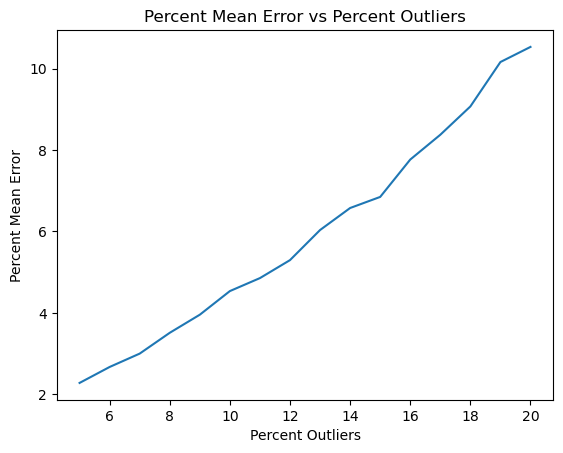

In [97]:
import matplotlib.pyplot as plt
x = []
y = []
for key, value in final.items():
    x.append(key)
    y.append(value[0])
plt.plot(x,y)
plt.title("Percent Mean Error vs Percent Outliers")
plt.xlabel("Percent Outliers")
plt.ylabel("Percent Mean Error")

dict

In [80]:
#This cell runs the algorithm at varying degrees of thresholds
final = dict()
for t in range(5):
    t = t* .5 +2
    np.random.seed(1)
    percent_mean_errors = []
    percent_std_errors = []

    
    for i in range(10000):
        array, true_mean, true_std = create_array(500)
        mean, std = algorithm(array, t)
        diff_in_means = mean - true_mean
        diff_in_std = std - true_std
        percent_mean_errors.append(abs(diff_in_means/true_mean) * 100)
        percent_std_errors.append(abs(diff_in_std/ true_std) * 100)
        
        
    final[t] = (np.mean(percent_mean_errors), np.mean(percent_std_errors))

In [81]:
final

{2.0: (14.215063812364003, 38.25293367238581),
 2.5: (4.6769522621203174, 8.38022830836227),
 3.0: (4.527668278475625, 2.1574237652498933),
 3.5: (6.332893391646013, 6.005760118801969),
 4.0: (9.195144712483348, 11.521729347033798)}

In [79]:
for o in range(5):
    print(str((o * .5) +2) )

2.0
2.5
3.0
3.5
4.0


In [85]:
for percent_o in range(5, 21, 1):
    print( int(10000 * percent_o/100))

500
600
700
800
900
1000
1100
1200
1300
1400
1500
1600
1700
1800
1900
2000


In [70]:
percent_mean_errors = []
percent_std_errors = []
np.random.seed(1)
for i in range(1000):

    # Generate data
    data = np.random.normal(loc=1, scale=1, size=4000)
    true_mean = np.mean(data)
    true_std = np.std(data)
   # print(true_std)

    # Generate an array of random floats between 0 and 11 for Outliers
    random_floats = np.random.uniform(0, 11, size=400)  # Adjust size as needed

    # Iterate through the random floats and insert them into random positions in 'data'
    for value in random_floats:
        random_index = random.randint(0, len(data) - 1)
        data[random_index] = value
        
        

    #print("Modified data:", data)

    # Initialize variables for running stats
    n = 0      # Count of valid values
    mean = 0   # Running mean
    M2 = 0     # Sum of squares of differences from the current mean
    threshold = 3  # Number of standard deviations to trim outliers

    # Loop through each value in the stream
    for value in data:
        # Outlier detection: only skip trimming for the first value
        if n > 1:
            # Calculate temporary standard deviation
            variance = M2 / (n - 1) if n > 1 else 0
            stddev = math.sqrt(variance)

            # Check if value is within threshold * stddev from the mean
            if abs(value - mean) > threshold * stddev:
                #print(f"Value {value} is considered an outlier and will be skipped.")
                continue

        # Update running statistics for non-outliers
        n += 1
        delta = value - mean
        mean += delta / n
        delta2 = value - mean
        M2 += delta * delta2

        # Compute the standard deviation fo#r the current set
        if n < 2:
            stddev = float('nan')  # Stddev undefined for the first value
        else:
            variance = M2 / (n - 1)
            stddev = math.sqrt(variance)

        # Output the running mean and standard deviation after each valid value
        #print(f"After {n} valid values: Mean = {mean}, Stddev = {stddev}")
    diff_in_means = mean - true_mean
    diff_in_std = stddev - true_std
    percent_mean_errors.append(abs(diff_in_means)/true_mean * 100)
    percent_std_errors.append(abs(diff_in_std)/ true_std * 100)
    

# print(f"Mean = {mean}")
# print(f"Stddev = {stddev}")

In [71]:
np.mean(percent_std_errors)

2.234326835641625

In [72]:
np.mean(percent_mean_errors)

4.332311526175828

In [35]:
np.mean(percent_mean_errors)

2.048211801355357